# STA for Hatano-Nelson Model (Truncation)

This notebook uses the Krylov expansion to numerically find AGP for Hatano-Nelson model. The Hamiltonian is given by:
$$
H(t) = \sum_{n=1}^{N-1} \left[\frac{J}{2} e^{a h(t)} c_n^\dagger c_{n+1}+ \frac{J}{2} e^{-a h(t)} c_{n+1}^\dagger c_n+ U\, c_n^\dagger c_n c_{n+1}^\dagger c_{n+1}\right]
$$

The Krylov space is truncated early to show convergence towards true AGP.

In [1]:
using LinearAlgebra, SparseArrays, Plots, ProgressMeter
include("Hatano_Nelson.jl")  #call the Hatano_Nelson module to build the Hamiltonian and its time derivative
using .Hatano_Nelson

include("KrylovKitAGP.jl") 
using .KrylovKitAGP

In [2]:
#setup the functions
function H_dHdt(t, τ)
    H_matrix, dHdt_matrix = Hatano_Nelson.build_H_and_dHdt(N, J, U, a, h0, τ, t) #return the Hamiltonian and its time derivative
    return Matrix(H_matrix), Matrix(dHdt_matrix)
end

function graph(a_list)
    plot(1:length(a_list), real.(a_list)) #plot the a coefficients to check their behavior
end;

comm(a,b) = a*b-b*a
function AGP_test(H, dHdt, H_CD)
    test_mat = comm(H, im*dHdt + comm(H,H_CD))
    return maximum(abs.(test_mat))
end;

In [3]:
using Base.Threads, ProgressMeter
function AGP_array(τ, M, target_dim)
    dt = τ / M
    J, U, a, h0 = 1.0, 1.0, 1.0, 0.1

    times = collect(0:dt:τ)  # time points for evolution

    AGP_list = Vector{Matrix{ComplexF64}}(undef, M)
    comm_test_list = Vector{Float64}(undef, M)
    p = Progress(M)

    @threads for j in 1:M
        t = times[j]
        H,dHdt = Hatano_Nelson.build_H_and_dHdt(N, J, U, a, h0, τ, t)
        H_cd = KrylovKitAGP.KrylovKit_AGP_finite(Matrix(H), Matrix(dHdt), target_dim) #construct the counter-diabatic Hamiltonian by adding the AGP to the original Hamiltonian
        AGP_list[j] = H + H_cd
        comm_test_list[j] = AGP_test(H, dHdt, H_cd)
        next!(p)
    end
    return AGP_list, comm_test_list
end

AGP_array (generic function with 1 method)

# Hamiltonian Simulation

In [5]:
# Initialize the state and compute the eigenvalues and eigenvectors of the initial Hamiltonian
N    = 6               #number of sites
Np   = Int64(N/2)              # half filling
J, U, a, h0, τ = 1.0, 1.0, 1.0, 0.1, 1.0
H0 = Hatano_Nelson.build_H_and_dHdt(N, J, U, a, h0, τ, 0.0)[1] #get the Hamiltonian at time t=0.0

Diagonalization = eigen(Matrix(H0))
eigvals, eigvecs = Diagonalization.values, Diagonalization.vectors

ψ = eigvecs[:,1]
ψ /= norm(ψ)

function ramp_evolution(τ; M=200) # Function to evolve the state using the ramp method
    dt = τ / M
    J, U, a, h0 = 1.0, 1.0, 1.0, 0.1

    times = collect(0:dt:τ)  # time points for evolution
    ψt = copy(ψ)

    # Evolution loop
    for t in times[1:end-1]
        H = Hatano_Nelson.build_H_and_dHdt(N, J, U, a, h0, τ, t)[1]
        U_mat = exp(-im * Matrix(H) * dt)  # exact exp (small dim)
        ψt = U_mat * ψt
        ψt /= norm(ψt)  # normalize at each step
    end
    # Final energy
    H_final = Hatano_Nelson.build_H_and_dHdt(N, J, U, a, h0, τ, τ)[1]
    E_end = ψt' * H_final * ψt

    eig_final = eigen(Matrix(H_final)).vectors


    return ψt, E_end, H_final
end

ramp_evolution (generic function with 1 method)

In [6]:
τ_list = collect(1:1:250) # List of τ values for ramp evolution
E_diff_list_abs = Vector{Float64}(undef, length(τ_list)) 

for (i, τ) in enumerate(τ_list) # Loop over each τ value
    ψ_final, E_end, _ = ramp_evolution(τ) # Evolve the state using the ramp method
    E_diff_list_abs[i] = abs(E_end - eigvals[1])
end

max_Eτ = maximum(E_diff_list_abs); # Find the maximum energy difference

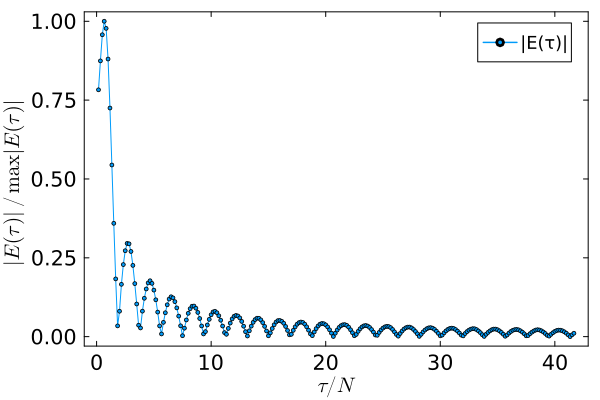

In [7]:
#Plot the results
using LaTeXStrings
p = plot(titlefontsize=18, guidefontsize=16, tickfontsize=14, legendfontsize=12, labelfontsize = 14, frame=:box,grid=false)
plot!(τ_list/N, E_diff_list_abs/max_Eτ, marker=:o, markersize = 2, label = "|E(τ)|")
plot!(xlabel=L"$τ/N$", ylabel=L"$|E(τ)|/\max|E(τ)|$", legend=:topright)

In [8]:
using Peaks  # utilities to find peaks in a 1D array

# find the indices of the local maxima in E_diff_list
peak_indices = argmaxima(E_diff_list_abs, 3)

# extract the corresponding τ values at those peak indices
τ_peaks = τ_list[peak_indices]

# keep only the peak values in E_diff_list (overwrites the original array)
E_diff_list_peaks = E_diff_list_abs[peak_indices];

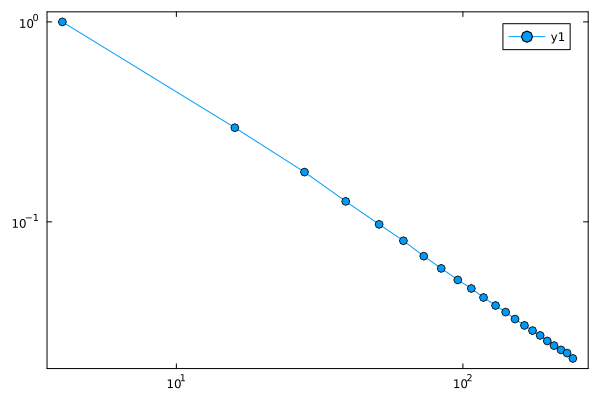

In [9]:
using LaTeXStrings
slope = round((log(E_diff_list_peaks[end]) - log(E_diff_list_peaks[1]))/(log(τ_peaks[end]) - log(τ_peaks[1])), digits = 2)
plot(τ_peaks, E_diff_list_peaks/max_Eτ, marker = :o ,xscale = :log10, yscale = :log10, grid = false, frame = :box)

# AGP Simulation

In [10]:
# We need to find the effect of AGP only at maxima points
println(τ_peaks)

[4, 16, 28, 39, 51, 62, 73, 84, 96, 107, 118, 130, 141, 152, 164, 175, 186, 197, 208, 220, 231, 242]


In [11]:
# # Initialize the state and compute the eigenvalues and eigenvectors of the initial Hamiltonian
J, U, a, h0 = 1.0, 1.0, 1.0, 0.1
H0 = Hatano_Nelson.build_H_and_dHdt(N, J, U, a, h0, τ, 0.0)[1] #get the Hamiltonian at time t=0.0

Diagonalization = eigen(Matrix(H0))
eigvals, eigvecs = Diagonalization.values, Diagonalization.vectors

ψ = eigvecs[:,1]
ψ /= norm(ψ)

function ramp_evolution_with_AGP(τ, M, target_dim) # Function to evolve the state using the ramp method
    dt = τ / M
    J, U, a, h0 = 1.0, 1.0, 1.0, 0.1

    times = collect(0:dt:τ)  # time points for evolution
    ψt = copy(ψ)

    AGP_list, AGP_err_list = AGP_array(τ, M, target_dim)

    # Evolution loop
    for j in 1:M
        t = times[j]
        H = AGP_list[j]
        U_mat = exp(-im * Matrix(H) * dt)  # exact exp (small dim)
        ψt = U_mat * ψt
        ψt /= norm(ψt)  # normalize at each step
    end
    # Final energy
    H_final = Hatano_Nelson.build_H_and_dHdt(N, J, U, a, h0, τ, τ)[1]
    E_end = ψt' * H_final * ψt

    #eig_final = eigen(Matrix(H_final)).vectors

    return ψt, E_end, AGP_err_list   #, H_final
end


ramp_evolution_with_AGP (generic function with 1 method)

In [12]:
function AGP_Simulation(M, target_dim, τ_peaks)
    τ_CD_list = τ_peaks # List of τ values for ramp evolution at the peaks
    E_diff_CD_list_abs = Vector{Float64}(undef, length(τ_CD_list)) 

    for i in 1:length(τ_CD_list)
        #println(i)
        τ = τ_CD_list[i]
        ψ_final, E_end, _ = ramp_evolution_with_AGP(τ, M, target_dim) # Evolve the state using the ramp method
        E_diff_CD_list_abs[i] = abs(E_end - eigvals[1])
    end
    return τ_CD_list, E_diff_CD_list_abs
end

AGP_Simulation (generic function with 1 method)

In [12]:
AGP_Simulation_50_20 = AGP_Simulation(100, 20, τ_peaks)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 

([5, 20, 34, 48, 62, 76, 90, 104, 118, 132, 145, 159, 173, 187, 201, 215, 229, 243], [0.006138254667450705, 0.0015193549628812332, 0.0009019590035004141, 0.0006608853390167902, 0.0005366240140717987, 0.00045318238477478343, 0.00040776947637626904, 0.00038379555166956304, 0.0003380065471430351, 0.00033359594115738673, 0.0003086712751153918, 0.00030309281843508254, 0.00029545172237847823, 0.0002900366742278358, 0.0002540355034405837, 0.0002788072145961792, 0.00023124877775441505, 0.0002681797549434591])

In [13]:
AGP_Simulation_50_50 = AGP_Simulation(100, 50, τ_peaks)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress: 100%|█████████████████████████████████████████| Time: 

([5, 20, 34, 48, 62, 76, 90, 104, 118, 132, 145, 159, 173, 187, 201, 215, 229, 243], [0.0012413026121047472, 0.0003636841445682826, 0.00027838224412476476, 0.00024596589332969625, 0.0002251620220565051, 0.00022736034021513923, 0.00020737835548006867, 0.00020793159373563215, 0.00020326043608766576, 0.00021134836906801309, 0.00019848297076041608, 0.00021269284247981625, 0.00020371042852928954, 0.00020659674424370987, 0.00019512545367521834, 0.00020840955165352557, 0.0001813542735404366, 0.00020597743494420105])

In [14]:
AGP_Simulation_50_80 = AGP_Simulation(100, 80, τ_peaks)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:02
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:02
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:02
Progress: 100%|█████████████████████████████████████████| Time: 0:00:02
Progress: 100%|█████████████████████████████████████████| Time: 0:00:02
Progress: 100%|█████████████████████████████████████████| Time: 0:00:02
Progress: 100%|█████████████████████████████████████████| Time: 

([5, 20, 34, 48, 62, 76, 90, 104, 118, 132, 145, 159, 173, 187, 201, 215, 229, 243], [0.00014534034300639866, 0.00020338267310881218, 0.000219330878492478, 0.00019112512044084203, 0.00020316576399388137, 0.00020872455059621684, 0.00020292855828766708, 0.00020307362585496267, 0.00020657436312652384, 0.000212579072543112, 0.00020567116024860734, 0.00021563576224555443, 0.00020608038502091414, 0.00020667716810755796, 0.00019572415396113067, 0.00021500464451514585, 0.0001795948804884091, 0.0002154167547070554])

In [15]:
#Plot the results  #20,50,80 are the truncated Krylov space dimension, only half is used for AGP construction
τ_CD_list_5020, E_diff_CD_list_abs_5020 = AGP_Simulation_50_20 
τ_CD_list_5050, E_diff_CD_list_abs_5050 = AGP_Simulation_50_50;
τ_CD_list_5080, E_diff_CD_list_abs_5080 = AGP_Simulation_50_80;

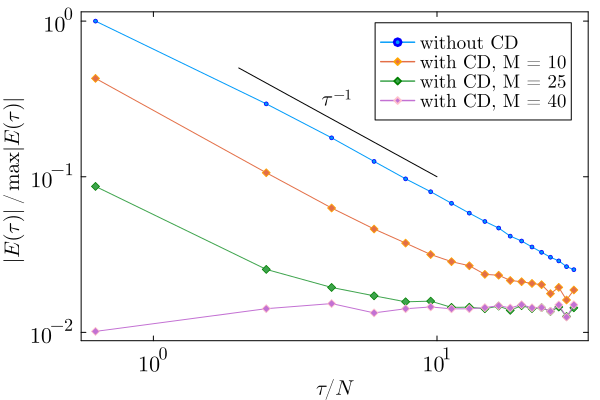

In [17]:
#Plot the results
x_axis = τ_peaks/N
using LaTeXStrings
m_size = 4
p = plot(titlefontsize=18, guidefontsize=16, tickfontsize=14, legendfontsize=12, labelfontsize = 14, frame=:box,grid=false, fontfamily = "Computer Modern")
plot!(x_axis, E_diff_list_peaks/max_Eτ, marker = :o, markersize = 2, markerstrokecolor = :blue,label = "without CD")
#plot!(x_axis, E_diff_CD_list_abs_5010/max_Eτ, marker=:diamond, markersize = 2, markerstrokecolor = :orange, label = "with CD, M = 10")
plot!(x_axis, E_diff_CD_list_abs_5020/max_Eτ, marker=:diamond, markersize = m_size, markerstrokecolor = :orange, label = "with CD, M = 10")
plot!(x_axis, E_diff_CD_list_abs_5050/max_Eτ, marker=:diamond, markersize = m_size, markerstrokecolor = :green, label = "with CD, M = 25")
plot!(x_axis, E_diff_CD_list_abs_5080/max_Eτ, marker=:diamond, markersize = m_size, markerstrokecolor = :pink, label = "with CD, M = 40")
plot!(xlabel=L"$τ/N$", ylabel=L"$|E(τ)|/\max|E(τ)|$", legend=:topright, xscale = :log, yscale = :log)
plot!(x -> x^(-1), 2:10, color = "black", label = nothing)
annotate!(4.5,(1/4.5+0.1), text(L"τ^{-1}"))
#savefig(p,"Energy_peak_M.pdf")